# Object Detection — Stage 1 (Localisation & Multi-Object Detection)

Trains `ObjectDetectorResNet` to predict up to `MAX_OBJECTS` bounding boxes per image.
Each predicted slot is `[x, y, w, h, conf]`; confidence is a raw logit trained with BCE.

**Pipeline:**  
`get_detection_loaders` → `ObjectDetectorResNet` → `DetectionLoss` → `fit()`


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch

from utils.dataset import get_detection_loaders
from utils.trainer import fit, evaluate_detection, evaluate_detection_sweep
from utils.visualizer import Visualizer
from utils.callbacks import ModelCheckpoint
from utils.losses import DetectionLoss
from models import get_detector

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 198
EPOCHS      = 60
MAX_OBJECTS = 24      # must match generator max_objects
CONF_THRESH = 0.7     # sigmoid threshold at inference
LAMBDA_CONF = 1.0     # weight on confidence loss
MODEL_SIZE  = 'l'

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device : cuda
PyTorch: 2.11.0+cu130


## 1 · Data Loaders


In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size = BATCH_SIZE,
    test=True,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
imgs, boxes, labels, mask = batch

print(f'Image batch shape : {imgs.shape}')
print(f'GT boxes shape    : {boxes.shape}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Image batch shape : torch.Size([198, 1, 224, 224])
GT boxes shape    : torch.Size([198, 15, 4])
Train batches: 1213 | Val batches: 76


## 2 · Model


In [3]:
model = get_detector(size=MODEL_SIZE, max_objects=MAX_OBJECTS).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    out = model(imgs.to(DEVICE))
print(f'Output shape: {out.shape}')  # (B, MAX_OBJECTS, 5) — [x, y, w, h, conf]


Parameters: 19,989,088
Output shape: torch.Size([198, 24, 52])


## 3 · Loss — Huber + BCE confidence

`DetectionLoss` lives in `utils/losses.py`:
- Greedy IoU match → each GT box assigned to the best predicted slot
- **Box loss**: `HuberLoss` on matched pairs
- **Conf loss**: `BCEWithLogitsLoss` — matched slots → 1.0, background → 0.0


In [4]:
criterion = DetectionLoss(lambda_conf=LAMBDA_CONF, delta=1.0, use_pos_weight=True)
print('DetectionLoss ready.')

# ── Quick loss smoke-test ─────────────────────────────────────────────────────
boxes_v = boxes.to(DEVICE)
mask_v = mask.to(DEVICE)

with torch.no_grad():
    dummy_out   = model(imgs.to(DEVICE))
    loss_val    = criterion(dummy_out, boxes_v, mask_v)
print(f'Smoke-test loss: {loss_val.item():.4f}')


DetectionLoss ready.
Smoke-test loss: 58.2945


## 4 · Optimiser & Scheduler


In [5]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
)

NAME = f"s_detector_{MODEL_SIZE}"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
    mode='max'   # maximise val_f1
)

scaler = torch.amp.GradScaler('cuda')

print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')


Optimizer : AdamW
Scheduler : OneCycleLR


## 5 · Train


In [6]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume      = True,
)


Training with bf16 autocast | Epochs: 60
[RunLogger] ▶  Run 's_detector_l_20260805_145842' started — saving to 'C:\OD-From-Scratch\logs\ObjectDetectorResNet\s_detector_l_20260805_145842.json'
Could not resume training: No checkpoint found at '..\checkpoint\s_detector_l_latest.pth'. Cannot resume training.
Batch  1 | match=1.00 hungar=1.8ms data=699.8ms pad=1.2ms forward=196.6ms loss=51.2ms backward=298.9ms step=140.3ms
Batch  2 | match=1.00 hungar=1.6ms data=0.2ms pad=0.8ms forward=52.1ms loss=7.0ms backward=108.7ms step=3.7ms
Batch  3 | match=1.00 hungar=1.3ms data=0.2ms pad=0.7ms forward=55.2ms loss=4.9ms backward=108.2ms step=3.8ms
Batch  4 | match=1.00 hungar=1.2ms data=0.1ms pad=0.8ms forward=52.2ms loss=4.4ms backward=107.8ms step=3.9ms
Batch  5 | match=1.00 hungar=1.2ms data=0.1ms pad=0.7ms forward=54.1ms loss=4.6ms backward=106.9ms step=3.8ms
  --> Epoch Average Match Ratio: 1.0000
Train: 210.8s | Val: 49.1s
  --> Det  | PR: 0.089 | Rec: 0.092 | F1: 0.090 | TP: 10991 FP: 112682

## 6 · Training Curves


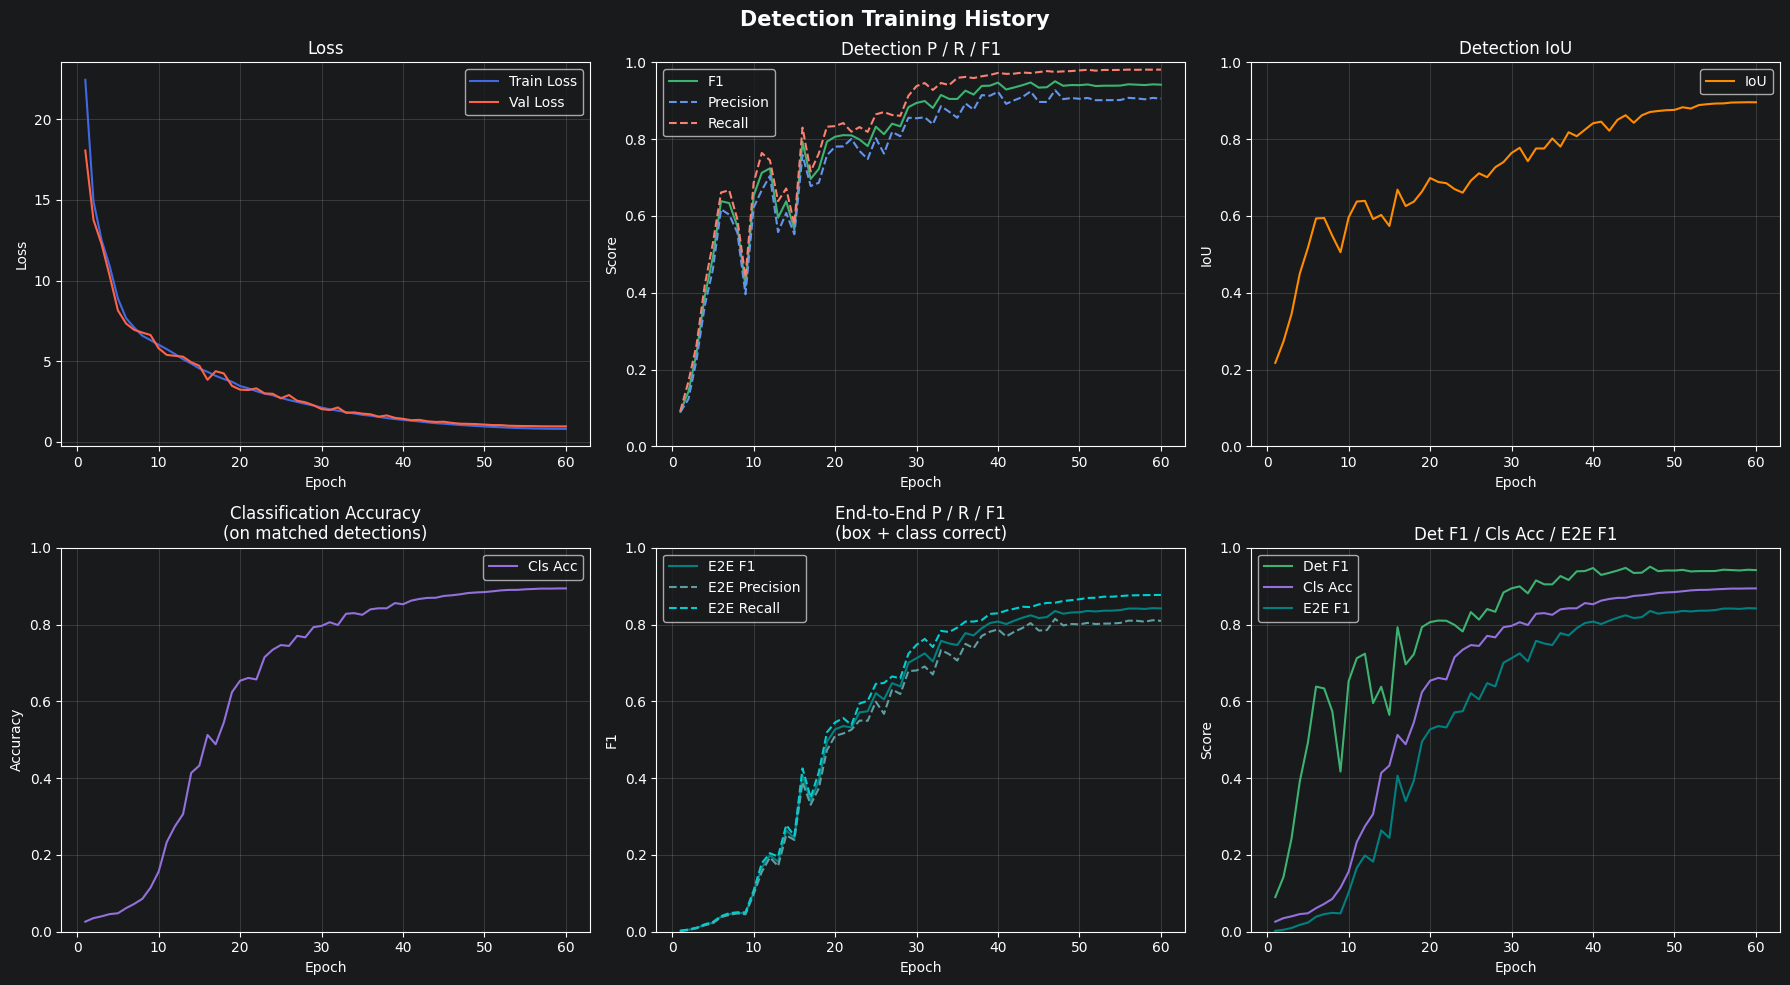

In [7]:
# Full detection training dashboard (Loss, Det P/R/F1, IoU, Cls Acc, E2E P/R/F1)
Visualizer.visualize_detection_history(history)


## 7 · Final Evaluation on Test Set


In [8]:
# Load best checkpoint weights if checkpoint callback was used
if 'checkpoint' in locals() and checkpoint is not None:
    checkpoint.restore_best_weights()

metrics = evaluate_detection(model, test_loader, criterion, DEVICE, conf_threshold=CONF_THRESH)

det = metrics['detection']
cls = metrics['classification']
e2e = metrics['end_to_end']

print('=== Detection (localisation) ===')
print(f"  Loss     : {metrics['loss']:.4f}")
print(f"  IoU      : {det['iou']:.4f}")
print(f"  Precision: {det['precision']:.4f}")
print(f"  Recall   : {det['recall']:.4f}")
print(f"  F1       : {det['f1']:.4f}")
print(f"  TP/FP/FN : {det['tp']} / {det['fp']} / {det['fn']}")

print('\n=== Classification (on matched detections) ===')
print(f"  Accuracy : {cls['accuracy']:.4f}")
print('  Per-class:')
for k, v in cls['per_class'].items():
    name = v.get('name', f'class_{k}')
    print(f"    [{k}] {name}: acc={v['accuracy']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}  e2e_f1={v['e2e_f1']:.4f}")

print('\n=== End-to-End (box + class correct) ===')
print(f"  Precision: {e2e['precision']:.4f}")
print(f"  Recall   : {e2e['recall']:.4f}")
print(f"  F1       : {e2e['f1']:.4f}")
print(f"  TP/FP/FN : {e2e['tp']} / {e2e['fp']} / {e2e['fn']}")


=== Detection (localisation) ===
  Loss     : 1.2482
  IoU      : 0.8704
  Precision: 0.9708
  Recall   : 0.9327
  F1       : 0.9514
  TP/FP/FN : 336317 / 10126 / 24250

=== Classification (on matched detections) ===
  Accuracy : 0.8636
  Per-class:
    [0] class_0: acc=0.5676  e2e_p=0.4977  e2e_r=0.5324  e2e_f1=0.5144
    [1] class_1: acc=0.4258  e2e_p=0.4904  e2e_r=0.3913  e2e_f1=0.4353
    [2] class_2: acc=0.9098  e2e_p=0.8429  e2e_r=0.8479  e2e_f1=0.8454
    [3] class_3: acc=0.9719  e2e_p=0.9198  e2e_r=0.9061  e2e_f1=0.9129
    [4] class_4: acc=0.9275  e2e_p=0.9111  e2e_r=0.8719  e2e_f1=0.8911
    [5] class_5: acc=0.9036  e2e_p=0.8658  e2e_r=0.8488  e2e_f1=0.8572
    [6] class_6: acc=0.9113  e2e_p=0.8976  e2e_r=0.8638  e2e_f1=0.8804
    [7] class_7: acc=0.9534  e2e_p=0.9166  e2e_r=0.8926  e2e_f1=0.9044
    [8] class_8: acc=0.9381  e2e_p=0.9313  e2e_r=0.8792  e2e_f1=0.9045
    [9] class_9: acc=0.6595  e2e_p=0.6417  e2e_r=0.6164  e2e_f1=0.6288
    [10] class_10: acc=0.9475  e2e_p=0.8

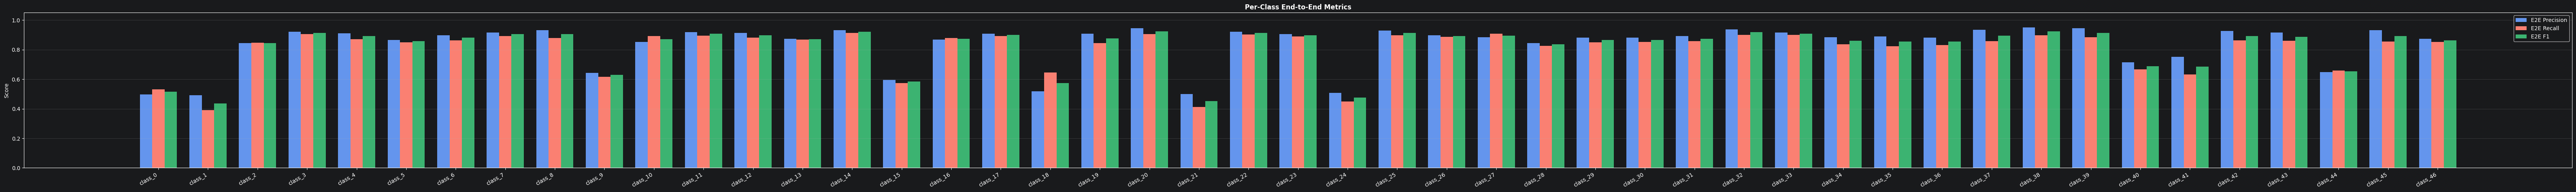

In [9]:
Visualizer.visualize_per_class_e2e(metrics)

## 8 · Prediction Visualisation

- **Lime** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH`


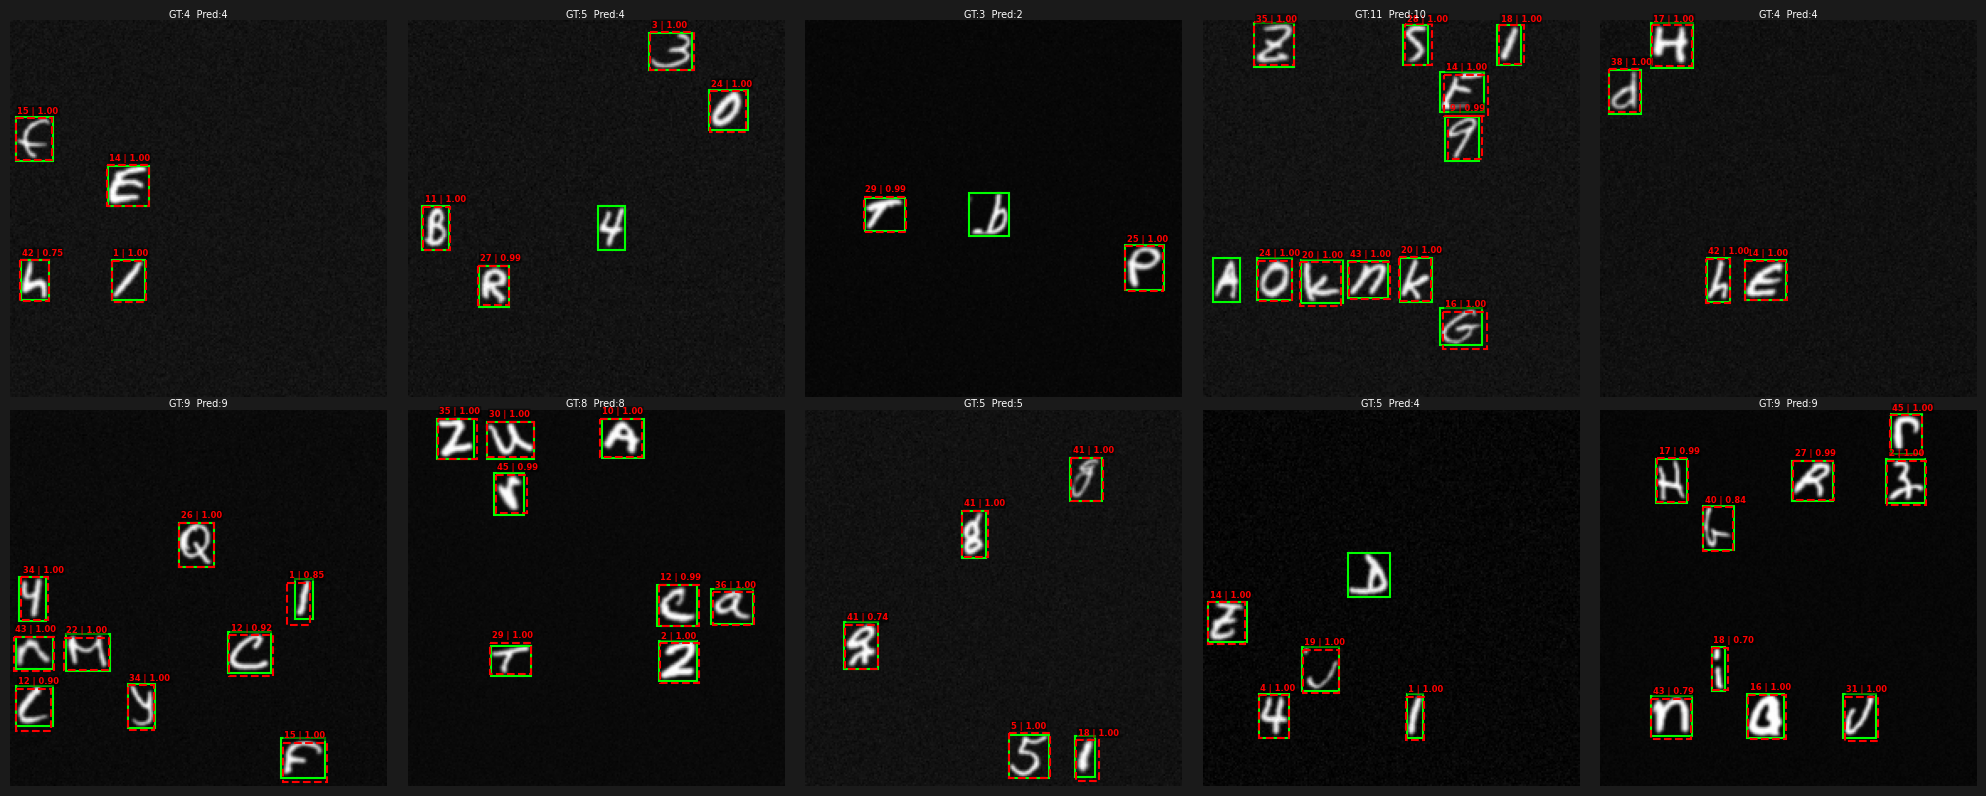

In [10]:
test_batch = next(iter(test_loader))
imgs_t, boxes_t, labels_t, mask_t = test_batch
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE)).cpu()

Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=preds_t,
    boxes_v=boxes_t,
    mask_v=mask_t,
    conf_thresh=CONF_THRESH,
)


## 9 · Confidence Threshold Sweep

Sweeps confidence thresholds on the held-out **test set** to see the full P/R/F1 trade-off.


In [11]:
sweep_results = evaluate_detection_sweep(
    model, test_loader, DEVICE,
    conf_thresholds=np.arange(0.1, 0.95, 0.05),
    iou_threshold=0.5,
    print_table=True,
)

if 'logger' in locals() and logger is not None:
    logger.log_test_results(sweep_results, iou_threshold=0.5)



  Conf       P       R      F1   ClsAcc       TP       FP       FN
------------------------------------------------------------------
  0.10  0.8043  0.9808  0.8838   0.8637   353643    86047     6924
  0.15  0.8188  0.9807  0.8924   0.8637   353614    78276     6953
  0.20  0.8319  0.9806  0.9001   0.8637   353556    71460     7011
  0.25  0.8453  0.9804  0.9078   0.8637   353488    64689     7079
  0.30  0.8589  0.9801  0.9155   0.8638   353375    58058     7192
  0.35  0.8737  0.9796  0.9236   0.8638   353220    51055     7347
  0.40  0.8909  0.9786  0.9327   0.8639   352834    43216     7733
  0.45  0.9089  0.9769  0.9417   0.8639   352221    35297     8346
  0.50  0.9271  0.9741  0.9500   0.8639   351220    27630     9347
  0.55  0.9422  0.9691  0.9555   0.8639   349423    21428    11144
  0.60  0.9546  0.9614  0.9580   0.8639   346659    16492    13908
  0.65  0.9639  0.9500  0.9569   0.8638   342524    12825    18043
  0.70  0.9708  0.9327  0.9514   0.8636   336317    10126    

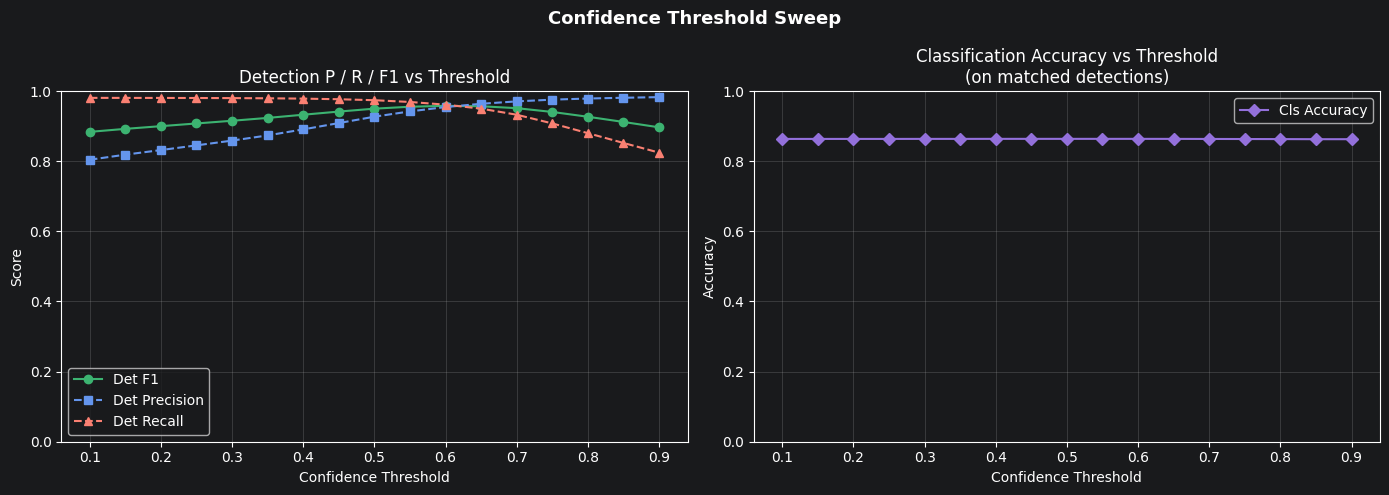


Best conf threshold : 0.60
  Det  F1  = 0.9580
  Cls  Acc = 0.8639
Per-class E2E F1:
  [0] class_0: e2e_f1=0.5178  e2e_p=0.4919  e2e_r=0.5466
  [1] class_1: e2e_f1=0.4394  e2e_p=0.4823  e2e_r=0.4035
  [2] class_2: e2e_f1=0.8535  e2e_p=0.8344  e2e_r=0.8734
  [3] class_3: e2e_f1=0.9184  e2e_p=0.9067  e2e_r=0.9305
  [4] class_4: e2e_f1=0.8957  e2e_p=0.8990  e2e_r=0.8925
  [5] class_5: e2e_f1=0.8636  e2e_p=0.8548  e2e_r=0.8727
  [6] class_6: e2e_f1=0.8826  e2e_p=0.8842  e2e_r=0.8810
  [7] class_7: e2e_f1=0.9097  e2e_p=0.9031  e2e_r=0.9165
  [8] class_8: e2e_f1=0.9116  e2e_p=0.9187  e2e_r=0.9047
  [9] class_9: e2e_f1=0.6294  e2e_p=0.6311  e2e_r=0.6276
  [10] class_10: e2e_f1=0.8766  e2e_p=0.8395  e2e_r=0.9172
  [11] class_11: e2e_f1=0.9106  e2e_p=0.9043  e2e_r=0.9170
  [12] class_12: e2e_f1=0.9048  e2e_p=0.9015  e2e_r=0.9080
  [13] class_13: e2e_f1=0.8768  e2e_p=0.8632  e2e_r=0.8908
  [14] class_14: e2e_f1=0.9270  e2e_p=0.9150  e2e_r=0.9392
  [15] class_15: e2e_f1=0.5860  e2e_p=0.5883  e2e

In [12]:
# Plot Det P/R/F1 and Cls Accuracy across thresholds
Visualizer.visualize_sweep_results(sweep_results)

# Per-class E2E F1 at best Det-F1 threshold
best_r = max(sweep_results, key=lambda r: r['f1'])
print(f"\nBest conf threshold : {best_r['conf']:.2f}")
print(f"  Det  F1  = {best_r['f1']:.4f}")
print(f"  Cls  Acc = {best_r['cls_accuracy']:.4f}")
print('Per-class E2E F1:')
for k, v in best_r['per_class_e2e'].items():
    name = v.get('name', f'class_{k}')
    print(f"  [{k}] {name}: e2e_f1={v['e2e_f1']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}")
